# Notebook 04 — Faster R-CNN Training
### Anti-UAV Drone Detection | AI447 Computer Vision

**What this notebook does:**
Trains **Faster R-CNN (ResNet-50-FPN backbone)** with 3 hyperparameter combinations (HP1, HP2, HP3).
Faster R-CNN is a **two-stage CNN-based** detector — it uses a Region Proposal Network (RPN) followed by a classification/regression head.
This is the **secondary architecture** for the report comparison.

**Key differences from YOLOv11:**
- Two-stage detection: RPN generates proposals, then they are classified & refined
- Slower inference than single-stage detectors (YOLO), but highly accurate
- Uses standard SGD with momentum (or Adam) — typical LR ~1e-3
- Backbone (ResNet-50) is ImageNet pretrained; FPN adds multi-scale feature maps
- NMS is applied on final box proposals

**Expected time on RTX 4050:** ~1.5–3 hours per combo at 800px

**Run after:** 


## 0 · Setup


In [1]:
import sys, os, time
from pathlib import Path

# ── Project root ─────────────────────────────────────────────
PROJECT_ROOT = Path(r'C:\Users\aljaf\uav_detection')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from src.training.hyperparams import load_config

# ── Paths ─────────────────────────────────────────────────────
DATA_ROOT    = PROJECT_ROOT / 'data'
CONFIGS_DIR  = PROJECT_ROOT / 'configs'
RUNS_DIR     = PROJECT_ROOT / 'runs' / 'train'
FIGURES_DIR  = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATASET_YAML = DATA_ROOT / 'dataset.yaml'

# ── Hardware ──────────────────────────────────────────────────
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
QUICK_TEST = False   # Set True for 5-epoch smoke test
EPOCHS     = 5 if QUICK_TEST else None

print(f'PyTorch:       {torch.__version__}')
print(f'Torchvision:   {torchvision.__version__}')
print(f'CUDA:          {torch.cuda.is_available()}')
if torch.cuda.is_available():
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU:           {torch.cuda.get_device_name(0)}  ({vram:.1f} GB)')
    torch.cuda.empty_cache()
print(f'Device:        {DEVICE}')

assert DATASET_YAML.exists(), f'dataset.yaml not found — run Notebook 01 first'
print(f'Data:          {DATASET_YAML} ✓')
print(f'Configs:       {CONFIGS_DIR} ✓' if CONFIGS_DIR.exists() else 'Run generate_configs.py first!')


PyTorch:       2.6.0+cu124
Torchvision:   0.21.0+cu124
CUDA:          True
GPU:           NVIDIA GeForce RTX 4050 Laptop GPU  (6.4 GB)
Device:        cuda
Data:          C:\Users\aljaf\uav_detection\data\dataset.yaml ✓
Configs:       C:\Users\aljaf\uav_detection\configs ✓


---
## 1 · Training function


In [2]:
import csv, json
import cv2
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from tqdm import tqdm
# ── 1. The YOLO to Faster R-CNN Adapter (SMART VERSION) ──────
# ── 1. The YOLO to Faster R-CNN Adapter (NO LEAKAGE VERSION) ──────
# ── 1. The YOLO to Faster R-CNN Adapter (DYNAMIC PATHS) ──────
class YOLODatasetAdapter(Dataset):
    def __init__(self, image_paths, imgsz=640):
        # We no longer need labels_dir because we will find it dynamically
        self.images = image_paths 
        self.imgsz = imgsz

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = Path(self.images[idx])
        
        # DYNAMIC PATHING: Go up one folder from 'images', then down into 'labels'
        # This works perfectly whether it's in 'merged/' or 'raw/val/'
        label_path = img_path.parent.parent / "labels" / f"{img_path.stem}.txt"
        
        img = cv2.imread(str(img_path))
        
        # SAFETY CHECK: Stop the silent OpenCV crash
        if img is None:
            raise FileNotFoundError(f"❌ OpenCV could not read image at: {img_path}")
            
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.imgsz, self.imgsz))
        img = torch.as_tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
        
        boxes = []
        labels = []
        
        if label_path.exists():
            with open(label_path, "r") as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        class_id, x_c, y_c, w, h = map(float, parts[:5])
                        
                        x1 = (x_c - w/2) * self.imgsz
                        y1 = (y_c - h/2) * self.imgsz
                        x2 = (x_c + w/2) * self.imgsz
                        y2 = (y_c + h/2) * self.imgsz
                        
                        boxes.append([x1, y1, x2, y2])
                        labels.append(1)

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels}
        return img, target

# ── 2. Model Builder ─────────────────────────────────────────
# ── 2. Model Builder ─────────────────────────────────────────
def build_faster_rcnn(num_classes: int = 2) -> torch.nn.Module:
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    
    # OVERRIDE TORCHVISION'S INTERNAL RESIZER FOR HP3
    model = fasterrcnn_resnet50_fpn(
        weights=weights, 
        min_size=1024,   # Force the minimum edge to 1024
        max_size=1024    # Force the maximum edge to 1024
    )
    
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

# ── 3. Training Loop ─────────────────────────────────────────
def train_fasterrcnn_combo(config_path, epochs_override=None, device_override=None):
    cfg = load_config(config_path)
    if epochs_override: cfg.epochs = epochs_override
    n_epochs = cfg.epochs
    device   = torch.device(device_override) if device_override else DEVICE
    lr       = cfg.lr
    batch    = cfg.batch_size
    wd       = cfg.weight_decay
    opt_name = cfg.optimizer

    print('=' * 64)
    print(f'Faster R-CNN Training: {cfg.hp_combination}')
    print(f'  Optimizer: {opt_name}  LR: {lr}  Batch: {batch}  Epochs: {n_epochs}  WD: {wd}')
    print('=' * 64)

# ── FIXING DATA LEAKAGE: USING PRE-DEFINED SPLITS ──
    splits_dir = DATA_ROOT / 'splits'

    # FIXED: Just read the exact path written in the text file
    def read_split_file(txt_path):
        with open(txt_path, 'r') as f:
            return [Path(line.strip()) for line in f.readlines() if line.strip()]

    # 1. Load the exact lists from your splits folder
    train_list = read_split_file(splits_dir / 'train.txt')
    val_list   = read_split_file(splits_dir / 'val.txt')
    
    if not train_list or not val_list:
        raise FileNotFoundError(f"❌ Split lists are empty! Check the splits directory: {splits_dir}")

    print(f"✅ Loaded predefined splits to prevent leakage: {len(train_list)} train, {len(val_list)} val")

    # 2. Pass the lists to our updated adapter (removed lbl_dir!)
    train_dataset = YOLODatasetAdapter(train_list, imgsz=cfg.imgsz)
    val_dataset   = YOLODatasetAdapter(val_list, imgsz=cfg.imgsz)
        
    train_loader  = DataLoader(train_dataset, batch_size=batch, shuffle=True,
                               num_workers=0, collate_fn=lambda x: tuple(zip(*x)))
    val_loader    = DataLoader(val_dataset, batch_size=1, shuffle=False,
                               num_workers=0, collate_fn=lambda x: tuple(zip(*x)))

    model = build_faster_rcnn(num_classes=2).to(device)

    params = [p for p in model.parameters() if p.requires_grad]
    if opt_name.lower() == 'sgd':
        optimizer = torch.optim.SGD(params, lr=lr, momentum=cfg.momentum, weight_decay=wd)
    else:
        optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=wd)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    run_dir = RUNS_DIR / f'fasterrcnn_{cfg.hp_combination}'
    run_dir.mkdir(parents=True, exist_ok=True)
    results_csv = run_dir / 'results.csv'

    history = []
    import time
    t0 = time.time()

    # YOLO-style header for the training summary
    print(f"\n{'Epoch':>10} {'total_loss':>12} {'cls_loss':>12} {'box_loss':>12} {'rpn_loss':>12} {'mAP50':>10} {'mAP50-95':>10}")
    print("-" * 84)

    for epoch in range(1, n_epochs + 1):
        model.train()
        train_loss = 0.0
        
        # Track individual losses for YOLO-style logging
        epoch_loss_classifier = 0.0
        epoch_loss_box_reg = 0.0
        epoch_loss_objectness = 0.0
        epoch_loss_rpn_box_reg = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{n_epochs} [Train]")
        for images, targets in pbar:
            images  = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            # Faster R-CNN returns a dictionary of specific losses
            loss_dict  = model(images, targets)
            losses     = sum(loss_dict.values())
            
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            
            # Accumulate losses
            train_loss += losses.item()
            epoch_loss_classifier += loss_dict.get('loss_classifier', torch.tensor(0.0)).item()
            epoch_loss_box_reg += loss_dict.get('loss_box_reg', torch.tensor(0.0)).item()
            epoch_loss_objectness += loss_dict.get('loss_objectness', torch.tensor(0.0)).item()
            epoch_loss_rpn_box_reg += loss_dict.get('loss_rpn_box_reg', torch.tensor(0.0)).item()
            
            pbar.set_description(f"Epoch {epoch}/{n_epochs} [Loss: {losses.item():.4f}]")
            
        scheduler.step()
        
        # Calculate averages for the epoch
        num_batches = max(len(train_loader), 1)
        train_loss /= num_batches
        avg_cls_loss = epoch_loss_classifier / num_batches
        avg_box_loss = epoch_loss_box_reg / num_batches
        avg_rpn_loss = (epoch_loss_objectness + epoch_loss_rpn_box_reg) / num_batches

        # ── VALIDATION STEP ──
        from torchmetrics.detection.mean_ap import MeanAveragePrecision
        metric = MeanAveragePrecision(iou_type='bbox')
        model.eval()
        
        with torch.no_grad():
            for images, targets in tqdm(val_loader, desc=f"Epoch {epoch}/{n_epochs} [Val  ]"):
                images  = [img.to(device) for img in images]
                preds   = model(images)
                metric.update(
                    [{k: v.cpu() for k, v in p.items()} for p in preds],
                    [{k: v.cpu() for k, v in t.items()} for t in targets],
                )
        
        map_result = metric.compute()
        map50    = float(map_result['map_50'])
        map5095  = float(map_result['map'])

        row = {
            'epoch':                   epoch,
            'train/total_loss':        round(train_loss, 5),
            'train/cls_loss':          round(avg_cls_loss, 5),
            'train/box_loss':          round(avg_box_loss, 5),
            'metrics/mAP50(B)':        round(map50, 5),
            'metrics/mAP50-95(B)':     round(map5095, 5),
        }
        history.append(row)
        
        # YOLO-style printout at the end of the epoch
        print(f"{f'{epoch}/{n_epochs}':>10} {train_loss:>12.4f} {avg_cls_loss:>12.4f} {avg_box_loss:>12.4f} {avg_rpn_loss:>12.4f} {map50:>10.4f} {map5095:>10.4f}")

    import pandas as pd
    df_hist = pd.DataFrame(history)
    df_hist.to_csv(results_csv, index=False)
    print(f'\n✅ Saved detailed results -> {results_csv}')

    torch.save(model.state_dict(), run_dir / 'best.pt')

    elapsed = time.time() - t0
    best_map = df_hist['metrics/mAP50(B)'].max()
    print(f'✅ fasterrcnn_{cfg.hp_combination} done in {elapsed/60:.1f} min')
    print(f'   Best mAP50: {best_map:.4f}')
    return "N/A (no MLflow)", df_hist

In [3]:
# Faster R-CNN uses native PyTorch — no Ultralytics / MLflow conflicts to clear.
print("✅ Ready to train Faster R-CNN")


✅ Ready to train Faster R-CNN


In [4]:
# Faster R-CNN weights are downloaded automatically by torchvision on first run.
# They are cached in: ~/.cache/torch/hub/checkpoints/
# Requires internet access for the first run only.
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
print("Faster R-CNN pretrained weights will be fetched from torchvision on first build.")
print(f"Default weights: {FasterRCNN_ResNet50_FPN_Weights.DEFAULT}")


Faster R-CNN pretrained weights will be fetched from torchvision on first build.
Default weights: FasterRCNN_ResNet50_FPN_Weights.COCO_V1


---
## 2 · Train HP1 — Baseline (SGD, lr=1e-3, no augmentation)


In [10]:
run_id_hp1, df_hp1 = train_fasterrcnn_combo(
    CONFIGS_DIR / 'fasterrcnn_hp1.yaml',
    epochs_override=EPOCHS,
)
print('HP1 done')


Faster R-CNN Training: hp1
  Optimizer: SGD  LR: 0.001  Batch: 4  Epochs: 15  WD: 0.0005
✅ Loaded predefined splits to prevent leakage: 11728 train, 2600 val

     Epoch   total_loss     cls_loss     box_loss     rpn_loss      mAP50   mAP50-95
------------------------------------------------------------------------------------


Epoch 1/15 [Val  ]: 100%|██████████| 2600/2600 [03:38<00:00, 11.92it/s]


      1/15       0.1218       0.0321       0.0579       0.0319     0.8559     0.5133


Epoch 2/15 [Val  ]: 100%|██████████| 2600/2600 [03:27<00:00, 12.51it/s]


      2/15       0.0888       0.0231       0.0470       0.0187     0.8806     0.5223


...

     13/15       0.0402       0.0108       0.0240       0.0055     0.8918     0.5620


Epoch 14/15 [Val  ]: 100%|██████████| 2600/2600 [03:50<00:00, 11.26it/s]


     14/15       0.0395       0.0106       0.0235       0.0054     0.8913     0.5628


Epoch 15/15 [Val  ]: 100%|██████████| 2600/2600 [03:27<00:00, 12.52it/s]


     15/15       0.0392       0.0105       0.0233       0.0054     0.8917     0.5629

✅ Saved detailed results -> C:\Users\aljaf\uav_detection\runs\train\fasterrcnn_hp1\results.csv
✅ fasterrcnn_hp1 done in 536.7 min
   Best mAP50: 0.9014
HP1 done


## 3 · Train HP2 — Best (AdamW, lr=1e-4, moderate augmentation)


In [6]:
run_id_hp2, df_hp2 = train_fasterrcnn_combo(
    CONFIGS_DIR / 'fasterrcnn_hp2.yaml',
    epochs_override=EPOCHS,
)
print('HP2 done')


Faster R-CNN Training: hp2
  Optimizer: AdamW  LR: 0.0001  Batch: 4  Epochs: 15  WD: 0.0001
✅ Loaded predefined splits to prevent leakage: 11728 train, 2600 val

     Epoch   total_loss     cls_loss     box_loss     rpn_loss      mAP50   mAP50-95
------------------------------------------------------------------------------------


Epoch 1/15 [Val  ]: 100%|██████████| 2600/2600 [03:46<00:00, 11.48it/s]


      1/15       0.1304       0.0342       0.0570       0.0392     0.8605     0.4570


Epoch 2/15 [Val  ]: 100%|██████████| 2600/2600 [03:24<00:00, 12.74it/s]


      2/15       0.1016       0.0262       0.0500       0.0254     0.8743     0.5157


...

     13/15       0.0151       0.0041       0.0087       0.0023     0.8892     0.5840


Epoch 14/15 [Val  ]: 100%|██████████| 2600/2600 [03:44<00:00, 11.59it/s]


     14/15       0.0124       0.0036       0.0069       0.0019     0.8893     0.5833


Epoch 15/15 [Val  ]: 100%|██████████| 2600/2600 [03:28<00:00, 12.44it/s]


     15/15       0.0109       0.0033       0.0059       0.0017     0.8889     0.5819

✅ Saved detailed results -> C:\Users\aljaf\uav_detection\runs\train\fasterrcnn_hp2\results.csv
✅ fasterrcnn_hp2 done in 550.4 min
   Best mAP50: 0.9107
HP2 done


## 4 · Train HP3 — Larger input (AdamW, lr=5e-5, 1024px)


In [5]:
run_id_hp3, df_hp3 = train_fasterrcnn_combo(
    CONFIGS_DIR / 'fasterrcnn_hp3.yaml',
    epochs_override=EPOCHS,
)
print('HP3 done')


Faster R-CNN Training: hp3
  Optimizer: AdamW  LR: 0.0001  Batch: 4  Epochs: 10  WD: 0.0001
✅ Loaded predefined splits to prevent leakage: 11728 train, 2600 val

     Epoch   total_loss     cls_loss     box_loss     rpn_loss      mAP50   mAP50-95
------------------------------------------------------------------------------------


Epoch 1/10 [Val  ]: 100%|██████████| 2600/2600 [06:29<00:00,  6.67it/s]


      1/10       0.1288       0.0360       0.0579       0.0349     0.8687     0.5226


Epoch 2/10 [Val  ]: 100%|██████████| 2600/2600 [05:57<00:00,  7.27it/s]


      2/10       0.0997       0.0265       0.0493       0.0238     0.8961     0.5420


...

      8/10       0.0323       0.0077       0.0186       0.0059     0.8999     0.6167


Epoch 9/10 [Val  ]: 100%|██████████| 2600/2600 [05:52<00:00,  7.38it/s]


      9/10       0.0252       0.0063       0.0142       0.0046     0.9091     0.6217


Epoch 10/10 [Val  ]: 100%|██████████| 2600/2600 [06:15<00:00,  6.92it/s]


     10/10       0.0204       0.0054       0.0111       0.0038     0.8996     0.6206

✅ Saved detailed results -> C:\Users\aljaf\uav_detection\runs\train\fasterrcnn_hp3\results.csv
✅ fasterrcnn_hp3 done in 1700.1 min
   Best mAP50: 0.9194
HP3 done


---
## 5 · Results Summary Table


In [7]:
import pandas as pd
# from pathlib import Path
# import yaml
# 
# PROJECT_ROOT = Path(__file__).resolve().parent.parent
# RUNS_DIR = PROJECT_ROOT / 'runs'
# CONFIGS_DIR = PROJECT_ROOT / 'configs'
# 
# def load_config(path):
#     with open(path, 'r') as f:
#         return yaml.safe_load(f) # Note: If using dicts, change dot notation below

def fetch_fasterrcnn_metrics(prefix):
    matched_folders = list(RUNS_DIR.glob(f'{prefix}*'))
    for folder_path in matched_folders:
        csv_path = folder_path / 'results.csv'
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            df.columns = df.columns.str.strip()
            best = df.loc[df['metrics/mAP50(B)'].idxmax()]
            return (
                round(best['metrics/mAP50(B)'], 4),
                round(best['metrics/mAP50-95(B)'], 4),
            )
    print(f"Warning: No metrics found for {prefix}")
    return 0, 0

def fmt_sci(v: float) -> str:
    s = f"{v:.0e}"
    return s.replace('e-0', 'e-').replace('e+0', 'e').replace('e+', 'e')

cfg_hp1 = load_config(CONFIGS_DIR / 'fasterrcnn_hp1.yaml')
cfg_hp2 = load_config(CONFIGS_DIR / 'fasterrcnn_hp2.yaml')
cfg_hp3 = load_config(CONFIGS_DIR / 'fasterrcnn_hp3.yaml')

hp1_map, hp1_map95 = fetch_fasterrcnn_metrics('fasterrcnn_hp1')
hp2_map, hp2_map95 = fetch_fasterrcnn_metrics('fasterrcnn_hp2')
hp3_map, hp3_map95 = fetch_fasterrcnn_metrics('fasterrcnn_hp3')

summary_rows = [
    {
        'Combo': 'HP1 — Baseline',
        'Optimizer': cfg_hp1.optimizer, # Ensure this is an object, not a dict
        'LR': fmt_sci(cfg_hp1.lr),
        'Batch': cfg_hp1.batch_size,
        'ImgSz': cfg_hp1.imgsz,
        'WD': fmt_sci(cfg_hp1.weight_decay),
        'val/mAP50': hp1_map,
        'val/mAP50-95': hp1_map95,
    },
    {
        'Combo': 'HP2 ',
        'Optimizer': cfg_hp2.optimizer,
        'LR': fmt_sci(cfg_hp2.lr),
        'Batch': cfg_hp2.batch_size,
        'ImgSz': cfg_hp2.imgsz,
        'WD': fmt_sci(cfg_hp2.weight_decay),
        'val/mAP50': hp2_map,
        'val/mAP50-95': hp2_map95,
    },
    {
        'Combo': 'HP3 — Large input',
        'Optimizer': cfg_hp3.optimizer,
        'LR': fmt_sci(cfg_hp3.lr),
        'Batch': cfg_hp3.batch_size,
        'ImgSz': cfg_hp3.imgsz,
        'WD': fmt_sci(cfg_hp3.weight_decay),
        'val/mAP50': hp3_map,
        'val/mAP50-95': hp3_map95,
    },
]

df_fasterrcnn = pd.DataFrame(summary_rows)
display_cols = ['Combo','Optimizer','LR','Batch','ImgSz','WD','val/mAP50','val/mAP50-95']
print('=== Faster R-CNN HP Combination Results ===')
print(df_fasterrcnn[display_cols].to_string(index=False))

csv_path = PROJECT_ROOT / 'reports' / 'fasterrcnn_hp_results.csv'
# Ensure the parent directory exists before saving
csv_path.parent.mkdir(parents=True, exist_ok=True) 
df_fasterrcnn.to_csv(csv_path, index=False)

print(f'\n✅ Saved -> {csv_path}')

=== Faster R-CNN HP Combination Results ===
            Combo Optimizer   LR  Batch  ImgSz   WD  val/mAP50  val/mAP50-95
   HP1 — Baseline       SGD 1e-3      4    640 5e-4     0.9014        0.5562
             HP2      AdamW 1e-4      4    640 1e-4     0.9107        0.5751
HP3 — Large input     AdamW 1e-4      4   1024 1e-4     0.9194        0.5973

✅ Saved -> C:\Users\aljaf\uav_detection\reports\fasterrcnn_hp_results.csv


---
## 6 · Learning Curves


Saved -> C:\Users\aljaf\uav_detection\reports\figures\fig_fasterrcnn_hp1_learning_curves.png


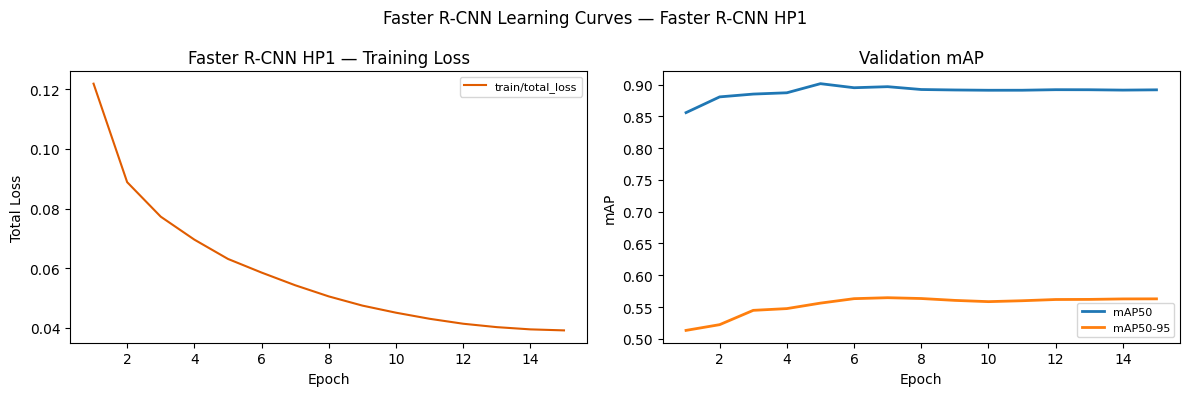

Saved -> C:\Users\aljaf\uav_detection\reports\figures\fig_fasterrcnn_hp2_learning_curves.png


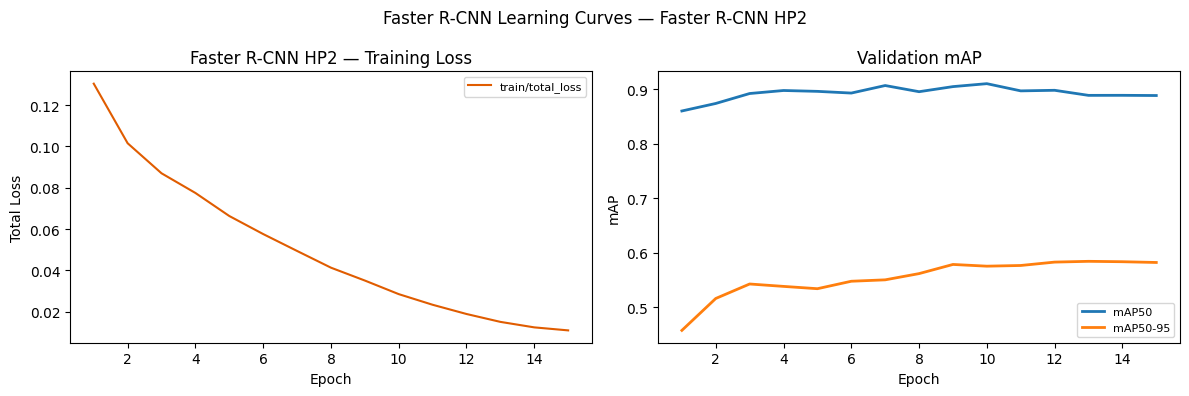

Saved -> C:\Users\aljaf\uav_detection\reports\figures\fig_fasterrcnn_hp3_learning_curves.png


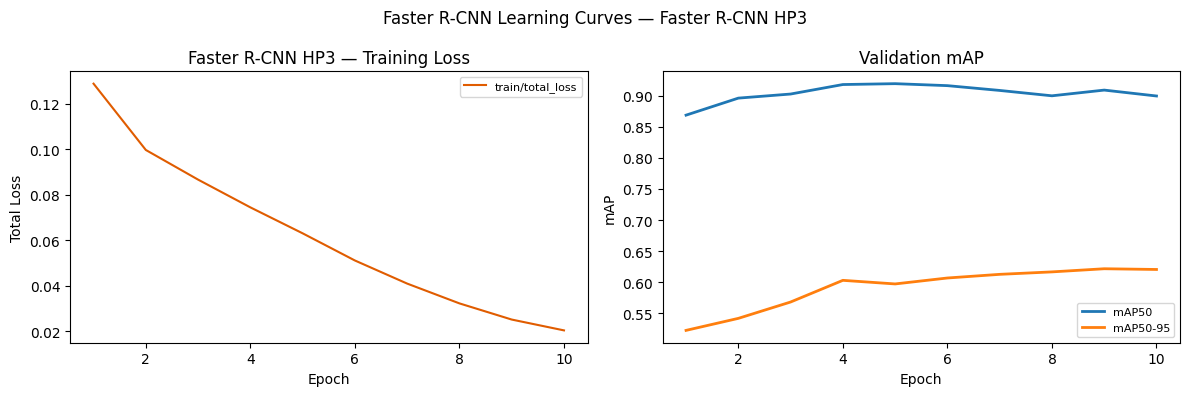

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

def plot_learning_curves(run_dir, hp_name, save_path=None):
    csv = run_dir / 'results.csv'
    if not csv.exists():
        print(f'⚠️  No results.csv found at {csv}')
        return
    df = pd.read_csv(csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Training loss
    if 'train/total_loss' in df.columns:
        axes[0].plot(df['epoch'], df['train/total_loss'], label='train/total_loss', color='#e05c00')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Total Loss')
    axes[0].set_title(f'{hp_name} — Training Loss'); axes[0].legend(fontsize=8)

    # Validation mAP
    for col, lbl in [('metrics/mAP50(B)', 'mAP50'), ('metrics/mAP50-95(B)', 'mAP50-95')]:
        if col in df.columns:
            axes[1].plot(df['epoch'], df[col], label=lbl, lw=2)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('mAP')
    axes[1].set_title('Validation mAP'); axes[1].legend(fontsize=8)

    plt.suptitle(f'Faster R-CNN Learning Curves — {hp_name}', fontsize=12)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved -> {save_path}')
    plt.show()

for hp in ('hp1', 'hp2', 'hp3'):
    matched_folders = list(RUNS_DIR.glob(f'fasterrcnn_{hp}*'))
    plot_successful = False
    for folder in matched_folders:
        if (folder / 'results.csv').exists():
            plot_learning_curves(
                folder,
                f'Faster R-CNN {hp.upper()}',
                FIGURES_DIR / f'fig_fasterrcnn_{hp}_learning_curves.png',
            )
            plot_successful = True
            break
    if not plot_successful:
        print(f'⚠️ No results.csv found for {hp}!')


---
## 7 · YOLOv11 vs Faster R-CNN Comparison


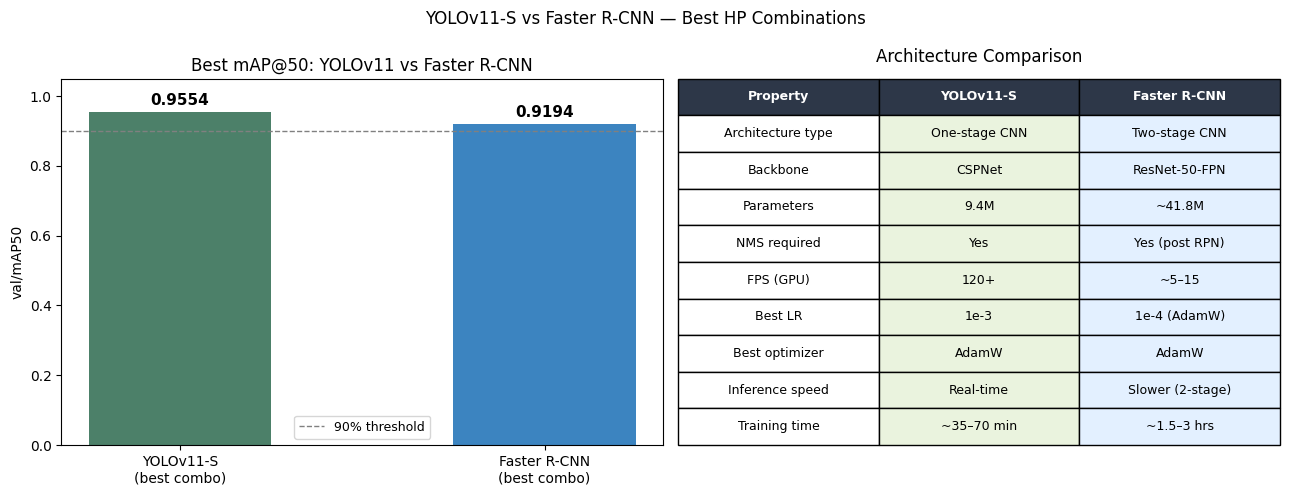


✅ Saved -> C:\Users\aljaf\uav_detection\reports\figures\fig_yolo_vs_fasterrcnn.png


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load YOLOv11 results from notebook 03
yolo_csv_path = PROJECT_ROOT / 'reports' / 'yolov11_hp_results.csv'

if yolo_csv_path.exists():
    df_yolo = pd.read_csv(yolo_csv_path)
    yolo_best_map50  = df_yolo['val/mAP50'].max()
    yolo_best_combo  = df_yolo.loc[df_yolo['val/mAP50'].idxmax(), 'Combo']
else:
    yolo_best_map50  = 0.9554   # your actual HP3 result
    yolo_best_combo  = 'HP3 — High-res ⭐'

frcnn_best_map50 = df_fasterrcnn['val/mAP50'].max()
frcnn_best_combo = df_fasterrcnn.loc[df_fasterrcnn['val/mAP50'].idxmax(), 'Combo']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — mAP50 bar comparison
ax = axes[0]
# FIXED: Used \n instead of physical line breaks
models   = ['YOLOv11-S\n(best combo)', 'Faster R-CNN\n(best combo)']
map_vals = [yolo_best_map50, frcnn_best_map50]
colors   = ['#2d6a4f', '#1a6fb5']

bars = ax.bar(models, map_vals, color=colors, alpha=0.85, width=0.5)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_ylabel('val/mAP50')
ax.set_title('Best mAP@50: YOLOv11 vs Faster R-CNN')
ax.axhline(0.9, color='gray', ls='--', lw=1, label='90% threshold')
ax.legend(fontsize=9)

# Right — architecture trade-off table
ax2 = axes[1]
ax2.axis('off')
table_data = [
    ['Property',          'YOLOv11-S',       'Faster R-CNN'],
    ['Architecture type', 'One-stage CNN',   'Two-stage CNN'],
    ['Backbone',          'CSPNet',          'ResNet-50-FPN'],
    ['Parameters',        '9.4M',            '~41.8M'],
    ['NMS required',      'Yes',             'Yes (post RPN)'],
    ['FPS (GPU)',         '120+',            '~5–15'],
    ['Best LR',           '1e-3',            '1e-4 (AdamW)'],
    ['Best optimizer',    'AdamW',           'AdamW'],
    ['Inference speed',   'Real-time',       'Slower (2-stage)'],
    ['Training time',     '~35–70 min',      '~1.5–3 hrs'],
]

tbl = ax2.table(cellText=table_data[1:], colLabels=table_data[0],
                cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)

for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2d3748')
        cell.set_text_props(color='white', fontweight='bold')
    elif c == 1:
        cell.set_facecolor('#EAF3DE')
    elif c == 2:
        cell.set_facecolor('#E3F0FF')

ax2.set_title('Architecture Comparison', pad=12)

plt.suptitle('YOLOv11-S vs Faster R-CNN — Best HP Combinations', fontsize=12)
plt.tight_layout()

# Ensure the directory exists before saving
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
save_path = FIGURES_DIR / 'fig_yolo_vs_fasterrcnn.png'

plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ Saved -> {save_path}')

---
## 8 · Summary


In [10]:
best = df_fasterrcnn.loc[df_fasterrcnn['val/mAP50'].idxmax()]

print('=' * 64)
print('FASTER R-CNN TRAINING COMPLETE')
print('=' * 64)
print(f'Best combo:  {best["Combo"]}')
print(f'  mAP@50:    {best["val/mAP50"]:.4f}')
print(f'  mAP@50-95: {best["val/mAP50-95"]:.4f}')

# FIXED: Replaced the physical line break with \n
print(f'\nYOLOv11 best:       {yolo_best_map50:.4f}  ({yolo_best_combo})')
print(f'Faster R-CNN best:  {frcnn_best_map50:.4f}  ({frcnn_best_combo})')

diff = yolo_best_map50 - frcnn_best_map50
if diff > 0:
    leader = 'YOLOv11 leads'
elif diff < 0:
    leader = 'Faster R-CNN leads'
else:
    leader = 'Tie'
print(f'Difference:         {diff:+.4f} ({leader})')

print()
print('Key insight for report:')
print('  Faster R-CNN uses a two-stage pipeline: RPN generates region proposals,')
print('  then a classification head refines them. This makes it highly accurate')
print('  but slower than single-stage detectors like YOLO — a classic')
print('  accuracy vs. speed trade-off for your report.')
print('  ResNet-50-FPN backbone provides rich multi-scale features (P2–P6).')
print()
print('Next → Open 05_YOLOv8_Baseline.ipynb')
print('=' * 64)

FASTER R-CNN TRAINING COMPLETE
Best combo:  HP3 — Large input
  mAP@50:    0.9194
  mAP@50-95: 0.5973

YOLOv11 best:       0.9554  (HP3 — High-res ⭐)
Faster R-CNN best:  0.9194  (HP3 — Large input)
Difference:         +0.0360 (YOLOv11 leads)

Key insight for report:
  Faster R-CNN uses a two-stage pipeline: RPN generates region proposals,
  then a classification head refines them. This makes it highly accurate
  but slower than single-stage detectors like YOLO — a classic
  accuracy vs. speed trade-off for your report.
  ResNet-50-FPN backbone provides rich multi-scale features (P2–P6).

Next → Open 05_YOLOv8_Baseline.ipynb
